In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.time import Time
from astropy.coordinates import EarthLocation,SkyCoord
from astropy import units as u
from astropy.coordinates import AltAz

import time
from datetime import datetime, timezone

from scipy.special import erf, spherical_jn
from scipy.integrate import cumulative_trapezoid

import sys
sys.path.append('../')
import analysis_utils as utils
utils.load_plotting_setting()

In [2]:
hbarc = 0.2     # eV um
rhoDM = 0.3e9        # dark matter mass density, eV/cm^3

deg2rad = np.pi / 180
rad2deg = 180 / np.pi

latitude_newhaven  = 41.31      # deg
longitude_newhaven = -72.923611 # deg

v_gal_rot = np.array([0, 220, 0])      # Galactic rotation speed in the Galactic frame; km/s
v_solar = np.array ([11.1, 12.2, 7.3]) # Solar motion in the Galactic frame

In [3]:
## Implement velocity transformations described in https://journals.aps.org/prd/abstract/10.1103/PhysRevD.84.023516
def unix_to_mjd(unix_time):
    return unix_time / 86400 + 40587

def get_T0_UT(unix_time):
    mjd = unix_to_mjd(unix_time)
    T0 = (int(mjd) - 55197.5) / 36525
    
    utc_dt = datetime.fromtimestamp(unix_time, timezone.utc)
    t = Time(utc_dt, scale='utc')
    ut_dt = t.ut1.value
    UT = ut_dt.hour + ut_dt.minute/60 + ut_dt.second/3600 + ut_dt.microsecond/(3600 * 1e6)

    return T0, UT

def get_lamb_t(unix_time):
    T0, UT = get_T0_UT(unix_time)

    L = 281.0298 + 36000.77 * T0 + 0.04107 * UT
    g = 357.9258 + 35999.05 * T0 + 0.04107 * UT

    ret = L + (1.915 - 0.0048 * T0) * np.sin(g * deg2rad) + 0.02 * np.sin(2 * g * deg2rad)
    return ret

def v_earth_rev(t):
    """Earth revolution speed around the sun in the Galactic frame
    Input time, `t`, should be in unix timestamp.
    """
    # Compute for only one time (no array)
    if not np.isscalar(t):
        raise('`t` should be a scalar')

    v_earth_orbital = 29.8   # km/s
    e = 0.016722  # ellipticity

    lamb_0 = 13   # deg
    # Ecliptic latitudes and longitudes (deg)
    beta = np.array([-5.5303, 59.575, 29.812])
    lamb = np.array([266.141, -13.3485, 179.3212])

    lamb_t = get_lamb_t(t) # in degree
    
    v_earth_orbital_t = v_earth_orbital * (1 - e * np.sin((lamb_t - lamb_0) * deg2rad ))
    ret_xg = v_earth_orbital_t * np.cos(beta[0] * deg2rad) * np.sin( (lamb_t - lamb[0]) * deg2rad)
    ret_yg = v_earth_orbital_t * np.cos(beta[1] * deg2rad) * np.sin( (lamb_t - lamb[1]) * deg2rad)
    ret_zg = v_earth_orbital_t * np.cos(beta[2] * deg2rad) * np.sin( (lamb_t - lamb[2]) * deg2rad)

    return np.array([ret_xg, ret_yg, ret_zg])

def v_earth_rot(t, long_lab, lat_lab):
    """Earth rotation speed in the Galactic frame
    Input time, `t`, should be in unix timestamp.
    """
    # Compute for only one time (no array)
    if not np.isscalar(t):
        raise('`t` should be a scalar')

    v_rot_eq = 0.465102  # Earth rotation speed at the equator; km/s
    lamb_lab = lat_lab

    v_rot_nwz = np.array([0, -1 * v_rot_eq * np.cos(lamb_lab * deg2rad), 0])
    v_rot_galactic = nwz_to_galactic(v_rot_nwz, t, long_lab, lat_lab)

    return v_rot_galactic

def get_LAST_deg(unix_time, longitude_loc):
    t = Time(unix_time, format='unix', scale='utc')
    lst = t.sidereal_time('apparent', longitude=longitude_loc).hour
    return lst * 15

def nwz_to_equatorial(vec_nwz, t, long_lab, lat_lab):
    # Input time, `t`, should be in unix timestamp
    if not np.isscalar(t):
        raise('`t` should be a scalar')

    if vec_nwz.shape == (3, ):
        vec_nwz = np.array([vec_nwz])

    t_lab_deg = get_LAST_deg(t, long_lab)
    lamb_lab  = lat_lab

    ret_xe = vec_nwz.T[0] * (-1) * np.sin(lamb_lab * deg2rad) * np.cos(t_lab_deg * deg2rad) + vec_nwz.T[1] * np.sin(t_lab_deg * deg2rad) + vec_nwz.T[2] * np.cos(lamb_lab * deg2rad) * np.cos(t_lab_deg * deg2rad)
    ret_ye = vec_nwz.T[0] * (-1) * np.sin(lamb_lab * deg2rad) * np.sin(t_lab_deg * deg2rad) - vec_nwz.T[1] * np.cos(t_lab_deg * deg2rad) + vec_nwz.T[2] * np.cos(lamb_lab * deg2rad) * np.sin(t_lab_deg * deg2rad)
    ret_ze = vec_nwz.T[0] * np.cos(lamb_lab * deg2rad) + vec_nwz.T[2] * np.sin(lamb_lab * deg2rad)

    return np.array([ret_xe, ret_ye, ret_ze]).T

def equatorial_to_nwz(vec_eq, t, long_lab, lat_lab):
    # Input time, `t`, should be in unix timestamp
    if not np.isscalar(t):
        raise('`t` should be a scalar')

    if vec_eq.shape == (3, ):
        vec_eq = np.array([vec_eq])

    t_lab_deg = get_LAST_deg(t, long_lab)
    lamb_lab  = lat_lab

    ret_n = vec_eq.T[0] * (-1) * np.sin(lamb_lab * deg2rad) * np.cos(t_lab_deg * deg2rad) - vec_eq.T[1] * np.sin(lamb_lab * deg2rad) * np.sin(t_lab_deg * deg2rad) + vec_eq.T[2] * np.cos(lamb_lab * deg2rad)
    ret_w = vec_eq.T[0] * np.sin(t_lab_deg * deg2rad) - vec_eq.T[1] * np.cos(t_lab_deg * deg2rad)
    ret_z = vec_eq.T[0] * np.cos(lamb_lab * deg2rad) * np.cos(t_lab_deg * deg2rad) + vec_eq.T[1] * np.cos(lamb_lab * deg2rad) * np.sin(t_lab_deg * deg2rad)+ vec_eq.T[2] * np.sin(lamb_lab * deg2rad)

    return np.array([ret_n, ret_w, ret_z]).T

def equatorial_to_galactic(vec_eq):
    if vec_eq.shape == (3, ):
        vec_eq = np.array([vec_eq])

    ret_xg = -0.06699 * vec_eq.T[0] - 0.8728 * vec_eq.T[1] - 0.4835 * vec_eq.T[2]
    ret_yg =  0.4927  * vec_eq.T[0] - 0.4503 * vec_eq.T[1] + 0.7446 * vec_eq.T[2]
    ret_zg = -0.8676  * vec_eq.T[0] - 0.1883 * vec_eq.T[1] + 0.4602 * vec_eq.T[2]
    
    return np.array([ret_xg, ret_yg, ret_zg]).T

def galactic_to_equatorial(vec_ga):
    if vec_ga.shape == (3, ):
        vec_ga = np.array([vec_ga])

    ret_xe = -0.06699 * vec_ga.T[0] + 0.4927 * vec_ga.T[1] - 0.8676 * vec_ga.T[2]
    ret_ye = -0.8728  * vec_ga.T[0] - 0.4503 * vec_ga.T[1] - 0.1883 * vec_ga.T[2]
    ret_ze = -0.4835  * vec_ga.T[0] + 0.7446 * vec_ga.T[1] + 0.4602 * vec_ga.T[2]
    
    return np.array([ret_xe, ret_ye, ret_ze]).T

def nwz_to_galactic(vec_nwz, t, long_lab, lat_lab):
    vec_eq = nwz_to_equatorial(vec_nwz, t, long_lab, lat_lab)
    vec_ga = equatorial_to_galactic(vec_eq)

    return vec_ga

def galactic_to_nwz(vec_ga, t, long_lab, lat_lab):
    vec_eq  = galactic_to_equatorial(vec_ga)
    vec_nwz = equatorial_to_nwz(vec_eq, t, long_lab, lat_lab)
    
    return vec_nwz

def v_lab_galactic(t, long_lab, lat_lab):
    v_rev = v_earth_rev(t)
    v_rot = v_earth_rot(t, long_lab, lat_lab)
    v_tot = v_gal_rot + v_solar + v_rev + v_rot

    return v_tot

#### Generate MC samples in the Galactic frame, then transform to the lab frame

In [4]:
def get_mb_galactic(n_mc, rng):
    """Generate random MC samples following a 3D Maxwell-Boltzmann distribution"""
    v0 = 220   # velocity dispersion; km/s
    sigmav = v0 / np.sqrt(2)

    # Velocity samples following a Maxwell-Boltzmann distribution
    v_ga_xyz = rng.normal(loc=0, scale=sigmav, size=3*n_mc)
    v_ga_xyz = np.reshape(v_ga_xyz, (n_mc, 3))

    return v_ga_xyz

def vel_boosted_galactic(v_dm, v_lab, vesc):
    """Velocity of DM in the Galactic frame, boosted by the lab velocity and truncated at escape velocity"""
    v_boosted = v_dm + v_lab
    v_absolute = np.sqrt(np.sum(v_boosted**2, axis=1))

    return v_boosted[v_absolute < vesc]

def nwz_to_altaz(vec_nwz):
    vec_norm = np.sqrt(np.sum(vec_nwz**2, axis=1))

    vec_n, vec_w, vec_z = vec_nwz.T[0], vec_nwz.T[1], vec_nwz.T[2]
    vec_horizontal = np.sqrt(vec_n**2 + vec_w**2)

    alt = np.arctan2(vec_z, vec_horizontal) * rad2deg
    az  = np.arctan2(-1*vec_w, vec_n) * rad2deg
    
    # Go from (-180, 180) to (0, 360) deg
    az[az < 0] = az[az < 0] + 360

    return np.array([vec_norm, alt, az]).T

def get_v_boosted_mc_nwz(v_dm_mc_ga, timestamp):
    vesc = 550 # km/s

    v_lab_ga = v_lab_galactic(timestamp, longitude_newhaven, latitude_newhaven)
    v_boosted_ga = vel_boosted_galactic(v_dm_mc_ga, v_lab_ga, vesc)
    v_boosted_nwz = galactic_to_nwz(v_boosted_ga, timestamp, longitude_newhaven, latitude_newhaven)

    return v_boosted_nwz

In [7]:
n_mc = 1000000
seed = 234837942783
rng = np.random.default_rng(seed=seed)

v_dm_ga = get_mb_galactic(n_mc, rng)

timestamp = 1751110052.777247
vesc = 550 # km/s

v_lab_ga = v_lab_galactic(timestamp, longitude_newhaven, latitude_newhaven)
v_boosted_ga = vel_boosted_galactic(v_dm_ga, v_lab_ga, vesc)
v_boosted_nwz = galactic_to_nwz(v_boosted_ga, timestamp, longitude_newhaven, latitude_newhaven)
vec_altaz = nwz_to_altaz(v_boosted_nwz)

vnorm = vec_altaz.T[0]
alts  = vec_altaz.T[1]
azs   = vec_altaz.T[2]

In [8]:
bins_alt = np.linspace(-90, 90, 50)
bins_az  = np.linspace(0, 360, 50)

hh_altaz, be_alt, be_az = np.histogram2d(alts, azs, bins=[bins_alt, bins_az])

In [9]:
# Calculate the cygnus position
observing_location = EarthLocation(lat=latitude_newhaven, lon=longitude_newhaven)
utc_dt = datetime.fromtimestamp(timestamp, timezone.utc)
observing_time = Time(utc_dt, scale='utc')
aa = AltAz(location=observing_location, obstime=observing_time)

# RA and Dec of Cygnus
coord_cygnus = SkyCoord(20.62 * 360/24, 42.03, unit=(u.degree, u.degree), frame='icrs')
altazs_cygnus = coord_cygnus.transform_to(aa)

alt_cygnus_deg = altazs_cygnus.alt.value
az_cygnus_deg  = altazs_cygnus.az.value

Text(0, 0.5, 'Altitude (deg)')

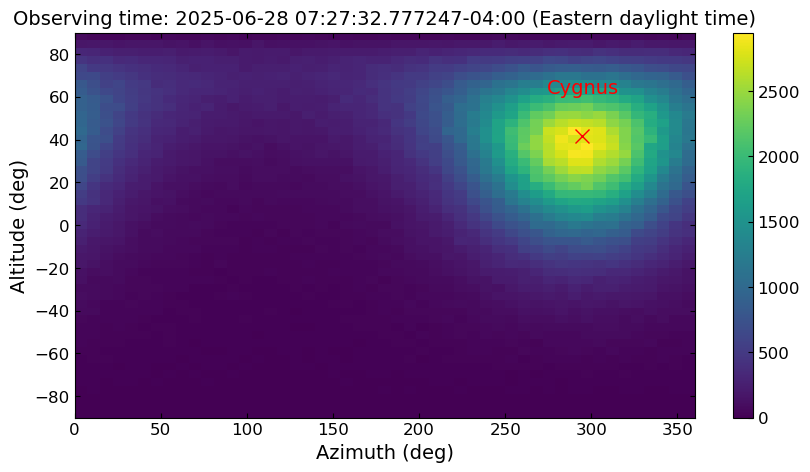

In [10]:
from zoneinfo import ZoneInfo

# Beware of the timezone here! It's eastern daylight time now so UTC-4
# inverted sign for fixed offsets in POSIX style
# For data taken in the winter should use UTC-5 instead (but only for book keeping)
utc_dt = datetime.fromtimestamp(timestamp, ZoneInfo("Etc/GMT+4"))

plt.figure(figsize=(10, 5))

plt.pcolormesh(bins_az, bins_alt, hh_altaz)
plt.plot(az_cygnus_deg, alt_cygnus_deg, 'rx', markersize=10)
plt.text(az_cygnus_deg-20, alt_cygnus_deg+20, 'Cygnus', color='r', fontsize=14)
plt.title(f'Observing time: {utc_dt} (Eastern daylight time)')

plt.colorbar()
plt.xlabel('Azimuth (deg)')
plt.ylabel('Altitude (deg)')

#### Check if the velocity distribution agrees with SHM

There is a tiny difference due to the motion of Earth relative to the Galactic rest frame.

In [11]:
from scipy.special import erf

def f_halo(v):
    ## DM parameters
    vesc  = 1.815e-3 # galactic escape velocity
    v0    = 7.34e-4  # v0 parameter from Zurek group paper
    ve    = 8.172e-4 # ve parameter from Zurek group paper

    """
    DM velocity distribution in the Earth frame from Zurek group paper
    https://journals.aps.org/prd/pdf/10.1103/PhysRevD.100.035025
    note there is a typo in the sign of the exponential in the above paper
    
    :param v: input velocity (array-like)
    :return: velocity distribtuion (array-like)
    """
    N0 = np.pi**1.5 * v0**3 * ( erf(vesc/v0) - 2/np.sqrt(np.pi) * (vesc/v0) * np.exp(-(vesc/v0)**2))
    
    # v < (vesc - ve)
    f1 = np.exp( - (v+ve)**2 / v0**2 ) * (np.exp(4*v*ve / v0**2) - 1)
    # (vesc - ve) < v < (vesc + ve)
    f2 = np.exp( - (v-ve)**2 / v0**2 ) - np.exp(- vesc**2 / v0**2)

    f = np.zeros_like(v)
    g1 = v < (vesc - ve)
    g2 = np.logical_and( vesc-ve < v, v < vesc + ve)
    
    f[g1] = f1[g1]
    f[g2] = f2[g2]

    return f * np.pi * v * v0**2 / (N0 * ve)

In [12]:
c_kms = 299792458 / 1000
vv_kms = np.linspace(1e-5, vesc, 200)
vv_c = vv_kms / c_kms

f_shm = f_halo(vv_c)

Text(0, 0.5, 'Velocity distribution, $f(v)$')

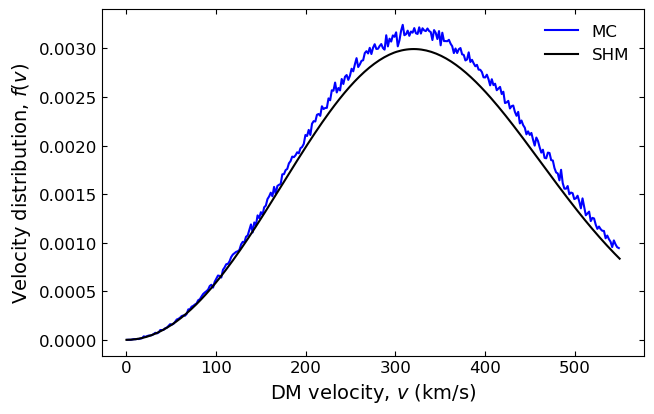

In [17]:
bins = np.linspace(0, vesc, 300)
bc = 0.5 * (bins[1:] + bins[:-1])
hh_v, _ = np.histogram(vnorm, bins, density=True)

plt.figure(figsize=(7, 4.5))
plt.plot(bc, hh_v, 'b', label='MC')
plt.plot(vv_kms, f_shm/c_kms, 'k', label='SHM')

plt.legend(frameon=False)
plt.xlabel('DM velocity, $v$ (km/s)')
plt.ylabel('Velocity distribution, $f(v)$')

#### Calculate the projected rate

In [34]:
def dsig_domega_born(mx, mphi, alpha, q, R=None, point_charge=True):
    """
    Differential cross section given by Born approximation

    :param mx : DM mass in natural units
    :param phi: mediator mass
    :param q  : momentum transfer (array_like)
    :param point_charge: if True give point charge solution
                         if False include a uniform sphere form factor

    :return: dsigma/domega in natural units (array_like)
    """
    point_charge_sol = (4 * (mx**2) * (alpha**2) ) / ( (mphi**2 + q**2)**2 )
    if point_charge:
        return point_charge_sol
    else:
        form_factor = 3 * spherical_jn(n=1, z=q*R) / (q * R)
        return point_charge_sol * form_factor**2
    
def dsig_dq(dsigdomega, mx, q, vlist):
    ss = np.empty(shape=(vlist.size, q.size))

    for i, v in enumerate(vlist):
        p = mx * v
        dsigdq = ( 2 * np.pi * q / (p**2) ) * dsigdomega

        # Cut off contribution below detection
        # Edit 2023/05/19: now done in later stages of analysis
        # dsigdq[q < q_thr] = 0

        # Cut off unphysical large-q scattering
        # This is necessary to get a realistic estimate
        # because Coulomb scattering xsec diverges
        dsigdq[q > 2 * p] = 0
        ss[i] = dsigdq
        
    return ss

def dR_dq(mx, mphi, alpha, q, vlist):
    # Differential cross section in the point charge limit
    dsigdomega = dsig_domega_born(mx, mphi, alpha, q, R=None, point_charge=True)
    dsigdq = dsig_dq(dsigdomega, mx, q, vlist)
        
    int_vec = rhoDM / mx * vlist * f_halo(vlist)
    
    # drdq, drdq_out = np.empty_like(q), np.empty_like(q)
    drdq = np.empty_like(q)
    for i in range(q.size):
        drdq[i] = np.trapz( int_vec * dsigdq.T[i], x=vlist )
        # drdq_out[i] = np.trapz( int_vec * dsigdq_out.T[i], x=vlist )
        
    # conv_fac = hbarc**2 * 1e9 * 3e10 * 1e-8 * 3600  # natural units -> um^2/GeV, c [cm/s], um^2/cm^2, s/hr
    conv_fac = hbarc**2 * 1e3 * 3e10 * 1e-8

    # keV; Differential count (Hz/keV/c)
    return q/1e3, drdq * conv_fac


In [81]:
# Direction of momentum transfer (z) in NWZ frame
z_dir_nwz = np.array([np.sin(20*deg2rad), np.cos(20*deg2rad), 0])

def get_dsdq(v, dsdq_v, vlist):
    """Interpolate to get the differential cross section dsig/dq at velocity v"""
    if v > vlist[-1]:
        return np.zeros_like(dsdq_v[0])

    # First index larger than v
    j_v = np.nonzero(vlist > v)[0][0]
    i_v = j_v - 1
    d_v = vlist[j_v] - vlist[i_v]

    _dsdq_i = dsdq_v[i_v]
    _dsdq_j = dsdq_v[j_v]

    # Interpolate between the two rates to the input alpha
    ret = _dsdq_i + (v - vlist[i_v]) * (_dsdq_j - _dsdq_i) / d_v
    return ret

def get_random_q_samples(qq, dsdq, rr, qmin):
    # print()
    if np.sum(dsdq[qq > qmin]) == 0:
        return None, None
    norm_factor = np.trapz(dsdq[qq > qmin], qq[qq > qmin])

    f_drdq_norm = dsdq[qq > qmin] / norm_factor       # PDF of q
    Fc_drdq_norm = cumulative_trapezoid(f_drdq_norm, x=qq[qq > qmin], initial=0) # CDF of q
    # Fc_drdq_norm = np.cumsum(f_drdq_norm) 

    qq_sampled = np.interp(rr, Fc_drdq_norm, qq[qq > qmin], left=0, right=0)
    return qq_sampled, norm_factor

def get_q_vectors(v_dm_nwz, q_mc, cosine_mc, phi_mc):
    v_hat = v_dm_nwz / np.sqrt(np.sum(v_dm_nwz**2))

    # Construct a local orthogonal basis
    # First choose an arbitrary vector not parallel to v_hat
    if abs(v_hat[0]) < 0.9:
        ref = np.array([1.0, 0.0, 0.0])
    else:
        ref = np.array([0.0, 1.0, 0.0])

    # First perpendicular vector
    u_hat = np.cross(v_hat, ref)
    u_hat /= np.linalg.norm(u_hat)
    
    # Second perpendicular vector (completes right-handed system)
    w_hat = np.cross(v_hat, u_hat)

    # Calculate the direction of DM momentum after scattering
    good_idx = np.logical_and(cosine_mc > -1, cosine_mc < 1)
    sine_mc = np.sin(np.arccos(cosine_mc[good_idx]))
    pf_dir = np.outer(cosine_mc[good_idx], v_hat) +  np.outer(sine_mc * np.cos(phi_mc[good_idx]), u_hat) + np.outer(sine_mc * np.sin(phi_mc[good_idx]), w_hat)

    # Get the normalized direction of momentum transfer q
    q_dir = v_hat - pf_dir
    q_dir_norm = np.sqrt(np.sum(q_dir**2, axis=1))
    q_dir = (q_dir.T / q_dir_norm).T

    ret   = (q_mc[good_idx] * q_dir.T).T

    # q vectors in eV/c
    return ret

def get_drdqz(v_dm_nwz, z_dir_nwz, mx, dsigdq_v, qq, vlist, rr0, rr1):
    """For each incoming DM velocity, find the projected scattering rate dR/dqz
    
    `rr0` and `rr1` are random uniform samples from 0 to 1
    """
    # First find the cross section dsig/dq for this velocity
    v_dm_norm_c = np.sqrt(np.sum(v_dm_nwz**2)) / c_kms
    px = mx * v_dm_norm_c

    dsdq = get_dsdq(v_dm_norm_c, dsigdq_v, vlist)

    # Generate MC samples above 1 MeV/c
    q_mc, norm_factor = get_random_q_samples(qq, dsdq, rr0, qmin=1e6)
    if q_mc is None:
        return None, None

    # Calculate the cosine of scattering angles
    cosine_mc = 1 - q_mc**2 / (2 * px**2)
    
    # Throw away unphysically large scattering angle
    if np.sum(cosine_mc > -1) == 0:
        return None, None

    phi_mc = rr1 * 2 * np.pi
    q_vectors_mc = get_q_vectors(v_dm_nwz, q_mc, cosine_mc, phi_mc)

    # Project onto z-axis and bin into histogram
    # Take the absolute value to account for both +z and -z
    qz_mc = np.abs(q_vectors_mc @ z_dir_nwz)

    bins = np.linspace(0, 10000000, 300)
    bc = 0.5 * (bins[1:] + bins[:-1])

    hhz, _ = np.histogram(qz_mc, bins=bins)
    dsigdqz = hhz * norm_factor / (np.sum(hhz)) / (bins[1] - bins[0])

    drdqz = (rhoDM / mx) * v_dm_norm_c * dsigdqz
    drdqz[bc < 1e6] = 0 # Disregard the rate calculated below 1 MeV
    
    conv_fac = hbarc**2 * 1e3 * 3e10 * 1e-8

    # keV/c; Events/keV/s
    return bc/1e3, drdqz * conv_fac

def get_projected_rate(v_dm_mc_nwz, z_dir_nwz, mx, dsigdq_v, qq, vlist, rr0, rr1):
    """
    `v_dm_mc_nwz` is in km/s
    """
    qz_kev, drdqzs = None, None
    count = 0
    for i, v_dm in enumerate(v_dm_mc_nwz):
        _qz_kev, _drdqz = get_drdqz(v_dm, z_dir_nwz, mx, dsigdq_v, qq, vlist, rr0, rr1)
        if _qz_kev is None:
            continue

        if qz_kev is None:
            qz_kev = _qz_kev
            drdqzs = _drdqz
        else:
            drdqzs += _drdqz
        count += 1
        
    drdqzs /= count

    return qz_kev, drdqzs

In [5]:
## If want to directly calculate differential cross section dsig/sq for velocity v
## for the massless case, uncomment the below code

# R_um    = 0.083
# mphi    = 0
# mx      = 2e9
# alpha_n = 2e-7

# # Parameters
# rho_T = 2.0e3   # Sphere density, kg/m^3
# mAMU = 1.66e-27 # Neutron mass

# vmin = 5e-5      # minimum velocity to consider, natural units (c)
# vesc = 1.815e-3  # galactic escape velocity
# v0 = 7.34e-4     # v0 parameter from Zurek group paper
# ve = 8.172e-4    # ve parameter from Zurek group paper

# nvels = 200      # Number of velocities to include in integration

# nq    = 1000    # Number of momentum transfer to sample
# qmin  = 10e3    # Lowest momenturm transfer considered (eV)
# qmax  = 2 * mx * vesc

# R = R_um / hbarc       # Sphere radius, eV^-1
# N_T = 0.5 * ( 4/3 * np.pi * (R_um*1e-6)**3 ) * rho_T/mAMU # Number of neutrons
# alpha = alpha_n * N_T

# # Calculate differential cross section dsig/dq for each velocity
# qq = np.linspace(qmin, qmax, nq)
# vlist = np.linspace(vmin, vesc, nvels)

# dsigdomega = dsig_domega_born(mx, mphi, alpha, qq, point_charge=True)
# dsigdq_v = dsig_dq(dsigdomega, mx, qq, vlist)


In [6]:
npz = np.load('/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/dm_rate/daily_modulation/dsdqdv_nanosphere_5.29278e-01_1.23616e-06_1e+00.npz')
# npz = np.load('/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/dm_rate/daily_modulation/dsdqdv_nanosphere_1.77828e+00_2.09209e-07_1e+00.npz')
# npz = np.load('/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/dm_rate/daily_modulation/dsdqdv_nanosphere_4.68870e+03_1.74604e-05_1e+00.npz')

mx = npz['mx_gev'] * 1e9
qq = npz['q']
dsigdq_v = npz['dsdqdv']
vlist = npz['v']

In [91]:
n_mc = 10000
seed = 234837942783
rng = np.random.default_rng(seed=seed)

v_dm_ga = get_mb_galactic(n_mc, rng)

n_mc_dsdq = 10000
rr0 = rng.uniform(0, 1, n_mc_dsdq)
rr1 = rng.uniform(0, 1, n_mc_dsdq)

timestamps = np.array([1751110052, 1751110052+3600*4, 1751110052+3600*8, 1751110052+3600*12, 1751110052+86164.0905])
qzs = []
drdqzs = []
for t in timestamps:
    print(t)
    v_dm_nwz = get_v_boosted_mc_nwz(v_dm_ga, t)
    _qz, _drdqz = get_projected_rate(v_dm_nwz, z_dir_nwz, mx, dsigdq_v, qq, vlist, rr0, rr1)

    qzs.append(_qz)
    drdqzs.append(_drdqz)

1751110052.0
1751124452.0
1751138852.0
1751153252.0
1751196216.0905


Event rate > 1.5 MeV (Events/h)
0.24
0.42
0.08
0.07
0.24


Text(0, 0.5, 'Projected event rate, $dR/dq_z$ (Events/kev/s)')

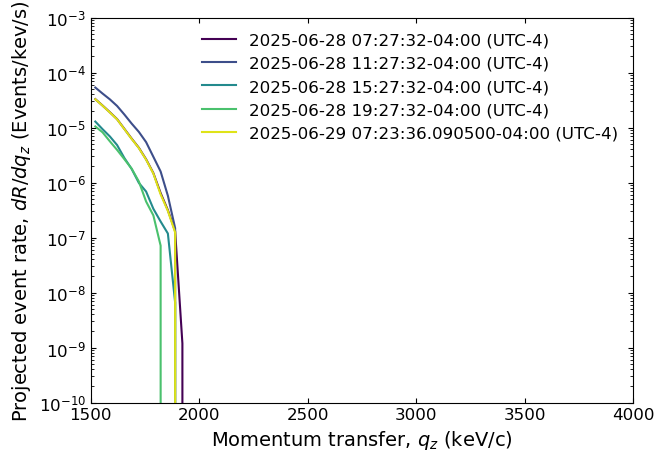

In [96]:
for i in range(5):
    utc_dt = datetime.fromtimestamp(timestamps[i], ZoneInfo("Etc/GMT+4"))
    qz, drdqz = qzs[i], drdqzs[i]
    plt.plot(qz[qz > 1500], 50 * drdqz[qz > 1500], label=f'{utc_dt} (UTC-4)')

    if i == 0:
        print('Event rate > 1.5 MeV (Events/h)')
    print(f'{np.trapz(drdqz[qz > 1500], qz[qz > 1500]) * 3600:.2f}')

plt.yscale('log')
plt.ylim(1e-10, 1e-3)
plt.xlim(1500, 4000)

plt.legend(frameon=False)
plt.xlabel('Momentum transfer, $q_z$ (keV/c)')
plt.ylabel('Projected event rate, $dR/dq_z$ (Events/kev/s)')

#### Load the calculated rate, smooth by resolution, and calculate the hourly event rate

In [12]:
import h5py
from astropy.time import Time

# a, b parameters for smearing
a, b = 1.31662664e+02, 6.33417842e-07

# Cut efficiency correction
chi2_cut_eff = 0.9538018099684543

data_dir = r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data/final_recon_before_bg_rate_cut'
# data_dir = r'/home/yt388/microspheres/dm_nanospheres/data_processed/sphere_data/final_recon_before_bg_rate_cut'
file1 = h5py.File(rf'{data_dir}/sphere_20250103_unbinned_amps.h5py')
time1 = file1['unbinned_amps']['time'][:]
file1.close()

# Get the timestamps of local sidereal time bins
def get_sidereal_bins(t0, lst_hour0, ndays):
    sday = 86164.0905

    begin = t0 - (lst_hour0 / 24) * sday
    bins_sidereal_timestamps = []
    for i in range(24 * ndays + 1):
        bins_sidereal_timestamps.append(begin + i * sday/24)

    t_bins = Time(bins_sidereal_timestamps, format='unix', scale='utc')
    lst_bins = t_bins.sidereal_time('apparent', longitude=longitude_newhaven).hour
    correction = (np.round(lst_bins) - lst_bins) * (sday/(24*3600))

    return np.asarray(bins_sidereal_timestamps) + correction

def sigma_q_kev(q, a, b):
    return a + b * q**2

def smear_drdqz_amp_gauss(qq, drdqz, a, b):
    """Convolve spectrum with a Gaussian kernel that has an amplitude-dependent 
    width a + b * x^2 (in keV/c)"""
    smeared_drdqz = np.empty_like(drdqz)
    dq = qq[1] - qq[0]

    qq_gauss = np.arange(-2000, 2000, dq)

    # Pad the array to minimize edge effect
    # to get the rising tail when q -> 0
    # then pad with mirror image
    pad_len = qq_gauss.size
    if qq[0] >= dq:
        padded_drdqz = np.pad(drdqz, (pad_len, 0), mode='symmetric')
    else:
        padded_drdqz = np.pad(drdqz, (pad_len, 0), mode='reflect')
    padded_drdqz = np.pad(padded_drdqz, (0, pad_len), mode='constant', constant_values=0)

    # Generate sigmas for different amplitudes
    sigma_q = sigma_q_kev(qq, a, b)
    for i, qi in enumerate(qq):
        sigma = sigma_q[i]
        gauss_kernel = utils.gauss(qq_gauss, A=1, mu=0, sigma=sigma)

        drdqz_to_convolve = padded_drdqz[pad_len//2+i : pad_len//2+i+qq_gauss.size]
        smeared_drdqz[i] = np.sum(drdqz_to_convolve * gauss_kernel) / np.sum(gauss_kernel)
    
    return qq, smeared_drdqz

def get_smeared_rate(qz, drdqz, qz_thr=1500):
    qz_smeared, drdqz_smeared = smear_drdqz_amp_gauss(qz, drdqz, a, b)
    drdqz_smeared *= chi2_cut_eff  # Correct for chi2 cut efficiency

    rate_hour = np.trapz(drdqz_smeared[qz_smeared > qz_thr], qz_smeared[qz_smeared > qz_thr]) * 3600
    return qz_smeared, drdqz_smeared, rate_hour

In [13]:
bins_sidereal_1 = get_sidereal_bins(time1[0], Time(time1[0], format='unix', scale='utc').sidereal_time('apparent', longitude=longitude_newhaven).hour, 22)
bins_siderealdays_1 = np.array([bins_sidereal_1[i] for i in range(bins_sidereal_1.size) if i % 24 == 0])

ndays = 22
# ndays = 8

timestamps = []
for i in range(ndays):
    timestamps.append(np.linspace(bins_siderealdays_1[i], bins_siderealdays_1[i+1], 200, endpoint=False))
timestamps = np.array(timestamps)

In [14]:
mx = 5.29278e-01 * 1e9
alpha_n = 1.23616e-06
m_phi = 1

rate = np.empty_like(timestamps)
qzs, drdqzs = [], []
for i in range(ndays):
    print(i)
    qz_list, drdqz_list = [], []

    for j, timestamp in enumerate(timestamps[i]):
        outdir = r'/home/yt388/palmer_scratch/data/dm_rate/daily_modulation'
        file_name = f'/drdqz_{mx:.5e}_{alpha_n:.5e}_{m_phi:.0e}_{int(timestamp)}.npz'

        npz = np.load(outdir+file_name)
        qz = npz['q_kev']
        drdqz = npz['drdqz_hz_kev']
        npz.close()

        qz_smeared, drdqz_smeared, rate_hour = get_smeared_rate(qz, drdqz, qz_thr=1500)
        rate[i, j] = rate_hour
        
        qz_list.append(qz_smeared)
        drdqz_list.append(drdqz_smeared)

    qzs.append(np.asarray(qz_list))
    drdqzs.append(np.asarray(drdqz_list))

qzs = np.array(qzs)
drdqzs = np.array(drdqzs)

0


FileNotFoundError: [Errno 2] No such file or directory: '/home/yt388/palmer_scratch/data/dm_rate/daily_modulation/drdqz_5.29278e+08_1.23616e-06_1e+00_1736027560.npz'

Text(0, 0.5, 'Events/keV/s')

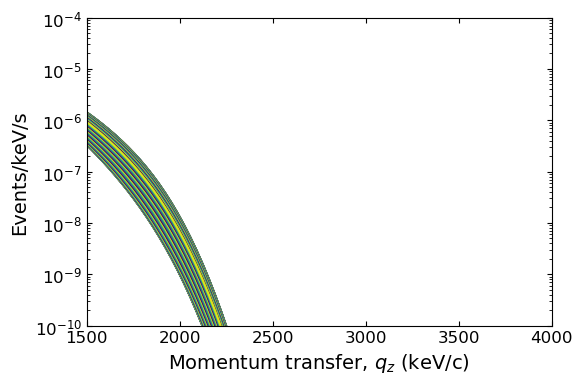

In [10]:
plt.subplots(1, 1, figsize=(6, 4))

for i, qz in enumerate(qzs[0]):
    plt.plot(qz, drdqzs[0][i])

plt.yscale('log')
plt.ylim(1e-10, 1e-4)
plt.xlim(1500, 4000)

plt.xlabel('Momentum transfer, $q_z$ (keV/c)')
plt.ylabel('Events/keV/s')

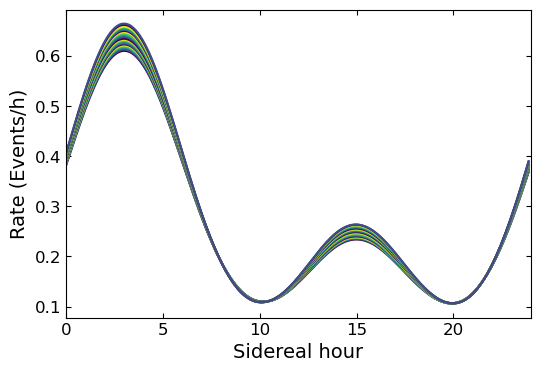

In [11]:
plt.subplots(1, 1, figsize=(6, 4))
for i in range(ndays):
    plt.plot(np.linspace(0, 24, 200, endpoint=False), rate[i])

plt.xlim(0, 24)
plt.xlabel('Sidereal hour')
plt.ylabel('Rate (Events/h)')

np.savez(r'/home/yt388/microspheres/dm_nanospheres/data_processed/dm_rate/daily_modulation/hourly_rate.npz',
         time=timestamps, hourly_rate=rate)